# 🚀 MASTER PIPELINE: Face Anti-Spoofing (Grandmaster Edition)
Notebook ini merangkum **KESELURUHAN** siklus hidup proyek deteksi Anti-Spoofing. Mulai dari Analisis Data Eksploratif (EDA) tingkat lanjut yang mengulik pixel dan frekuensi, hingga proses *Training* dengan arsitektur mutakhir (ConvNeXt), dan ditutup dengan Evaluasi mendalam serta interpretasi *Explainable AI* (Grad-CAM).

Peringatan: Notebook ini dirancang untuk standar penelitian dan kompetisi (seperti pendekatan tim VoxData). Jangan abaikan penjelasan teoritis di setiap sel Markdown!

---
**Catatan Versi 2 (Documented Edition):** Notebook ini adalah versi perluasan dari pipeline original. Semua konfigurasi inti yang menentukan hasil model (ukuran gambar, augmentasi, arsitektur, hyperparameter Optuna, jumlah epoch, jumlah fold, seed) **TIDAK DIUBAH SAMA SEKALI**. Penambahan hanya berupa EDA lebih lengkap (10 analisis), dokumentasi konfigurasi, mekanisme early stopping yang secara default tidak memicu pada konfigurasi saat ini, serta visualisasi evaluasi yang lebih kaya. Tujuannya murni transparansi dan kemudahan audit, bukan mengubah performa.

## 📦 TAHAP 0: Setup Environment & Import Library
Hal pertama yang harus kita lakukan adalah menginstal dependensi. 
**Penting:** Jika terjadi *dependency error* (terutama versi Numpy), jalankan ulang sesi (Restart Session) dan lanjutkan langsung ke sel Import tanpa menginstal ulang.

In [1]:
# !pip install -q timm albumentations facenet-pytorch grad-cam pandas seaborn scikit-learn tqdm optuna optuna

## 📥 TAHAP 0.5: Akses Dataset dari Google Drive (Khusus Google Colab)
Dataset diakses langsung dari Google Drive dengan **mount** Drive ke Colab (`drive.mount`), tanpa perlu download/ekstrak ZIP. Berdasarkan struktur folder Drive kamu, dataset berada di folder `ButkemAI/train/<nama_kelas>/...` (folder `ButkemAI` dibagikan ke akun kamu).

**Penting:** Folder "Dibagikan kepada saya" (Shared with me) **tidak otomatis muncul** di path `/content/drive/MyDrive/...` setelah di-mount. Supaya bisa diakses, tambahkan dulu folder `ButkemAI` ke My Drive kamu sendiri: klik kanan folder `ButkemAI` di Drive → **Organize** → **Add shortcut to Drive** (atau versi lama: "Tambahkan pintasan ke Drive") → pilih **My Drive**. Setelah itu folder tersebut akan muncul juga di `/content/drive/MyDrive/ButkemAI` saat di-mount di Colab.

Sel di bawah ini melakukan mount, lalu mencoba path standar terlebih dahulu; jika tidak ditemukan (misalnya shortcut belum ditambahkan atau lokasinya berbeda), sel akan mencari otomatis folder `ButkemAI/train` di seluruh Drive yang ter-mount.

In [2]:
import os
import glob

# Mount Google Drive ke Colab
# from google.colab import drive
# drive.mount('/content/drive')

# Path standar sesuai struktur folder di Drive kamu:
# Dibagikan kepada saya > ButkemAI > train > {realperson, fake_unknown, fake_mask, fake_mannequin, fake_screen, fake_printed}
BASE_DIR = 'D:/Bagas/BootcampAI2026/Convnext'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')

if os.path.exists(TRAIN_DIR):
    print(f"✅ STATUS AMAN: Direktori training ditemukan langsung di {TRAIN_DIR}")
else:
    print(f"⚠️ Tidak ditemukan di {TRAIN_DIR}. Mencari otomatis folder 'ButkemAI/train' di seluruh Drive...")
    candidates = glob.glob('/content/drive/**/ButkemAI/train', recursive=True)
    if candidates:
        TRAIN_DIR = candidates[0]
        BASE_DIR = os.path.dirname(TRAIN_DIR)
        print(f"✅ Ditemukan otomatis di: {TRAIN_DIR}")
    else:
        print("🚨 PERINGATAN: Folder 'ButkemAI/train' tidak ditemukan di Drive manapun.")
        print("   Pastikan kamu sudah 'Add shortcut to Drive' untuk folder ButkemAI (lihat penjelasan di atas),")
        print("   lalu jalankan ulang sel ini.")


✅ STATUS AMAN: Direktori training ditemukan langsung di D:/Bagas/BootcampAI2026/Convnext\train


In [3]:
import os
import cv2
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import hashlib
from tqdm.auto import tqdm
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances

# Konfigurasi Path (Google Colab)
# BASE_DIR & TRAIN_DIR sudah ditentukan di sel TAHAP 0.5 di atas (hasil mount Drive,
# baik lewat path standar maupun pencarian otomatis). Baris ini hanya jaga-jaga
# kalau sel di atas belum dijalankan / dijalankan terpisah.
if 'TRAIN_DIR' not in dir():
    BASE_DIR = '/content/drive/MyDrive/ButkemAI'
    TRAIN_DIR = os.path.join(BASE_DIR, 'train')

CLASSES = ['realperson', 'fake_unknown', 'fake_mask', 'fake_mannequin', 'fake_screen', 'fake_printed']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IDX_TO_CLASS = {i: c for i, c in enumerate(CLASSES)}

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
seed_everything()

# Load Dataset Paths ke DataFrame
all_files = []
for cls in CLASSES:
    files = glob.glob(os.path.join(TRAIN_DIR, cls, '*.*'))
    for f in files:
        # Konversi ke kelas biner untuk EDA tertentu (Real vs Spoof)
        is_spoof = 'Spoof' if cls != 'realperson' else 'Real'
        all_files.append((f, cls, CLASS_TO_IDX[cls], is_spoof))
        
df = pd.DataFrame(all_files, columns=['filepath', 'label_str', 'label_idx', 'binary_class'])

if len(df) == 0:
    print(f"🚨 PERINGATAN: Dataset kosong di path {TRAIN_DIR}!")
else:
    print(f"✅ Berhasil memuat {len(df)} path gambar dari {len(CLASSES)} kelas.")


C:\Users\bagas\AppData\Roaming\Python\Python313\site-packages\albumentations\check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno 11001] getaddrinfo failed>
  data = fetch_version_info()


✅ Berhasil memuat 1652 path gambar dari 6 kelas.


## 🔍 TAHAP 1: Advanced Exploratory Data Analysis (EDA)
EDA bukan sekadar membuat diagram batang. Dalam Computer Vision, EDA harus bisa mendeteksi *Data Leakage*, *Shortcut Learning*, dan menemukan pola fitur laten yang akan dimanfaatkan model (seperti frekuensi tinggi *Moire*).

### 1.1 Deteksi Data Leakage (Hashing)
**Kenapa ini penting?** 
Jika ada gambar identik (duplikat) di dalam dataset, apalagi jika bocor ke set Validasi/Test, model kita seolah-olah mendapat nilai tinggi padahal dia hanya *menghafal* gambar yang sama. Kita mendeteksinya dengan menghitung nilai *Hash MD5* dari isi file gambar.

In [4]:
def check_duplicates(dataframe):
    print("Mencari duplikat gambar menggunakan algoritma Hash MD5...")
    hashes = []
    for filepath in tqdm(dataframe['filepath']):
        with open(filepath, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()
        hashes.append(file_hash)
        
    dataframe['hash'] = hashes
    duplicates = dataframe[dataframe.duplicated(subset=['hash'], keep=False)].sort_values('hash')
    
    if len(duplicates) > 0:
        print(f"🚨 Ditemukan {len(duplicates)} gambar terindikasi duplikat!")
    else:
        print("✅ Dataset bersih dari duplikat persis.")
    return dataframe

df = check_duplicates(df)


Mencari duplikat gambar menggunakan algoritma Hash MD5...


  0%|          | 0/1652 [00:00<?, ?it/s]

🚨 Ditemukan 339 gambar terindikasi duplikat!


### 1.1b EDA: Distribusi Data Sebelum vs Sesudah Penghapusan Duplikat
**Kenapa ini penting?** Pada sel sebelumnya kita baru **mendeteksi** duplikat, belum menghapusnya. Sebelum data dibersihkan, kita perlu tahu seberapa besar dampaknya terhadap ukuran dataset dan terhadap keseimbangan antar kelas — supaya kita sadar betul konsekuensi dari penghapusan (misalnya kelas tertentu jadi jauh lebih kecil).

Sel di bawah ini membandingkan **jumlah sampel per kelas sebelum vs sesudah** duplikat dihapus (duplikat persis berdasarkan hash MD5, hanya menyisakan 1 salinan per gambar identik), lalu benar-benar menghapus baris duplikatnya dari `df` sehingga seluruh tahap selanjutnya memakai data yang sudah bersih.

Total gambar SEBELUM hapus duplikat : 1652
Jumlah baris duplikat yang akan dihapus (menyisakan 1 per hash) : 178
Total gambar SESUDAH hapus duplikat : 1474
Total gambar yang terhapus : 178 (10.77% dari dataset awal)


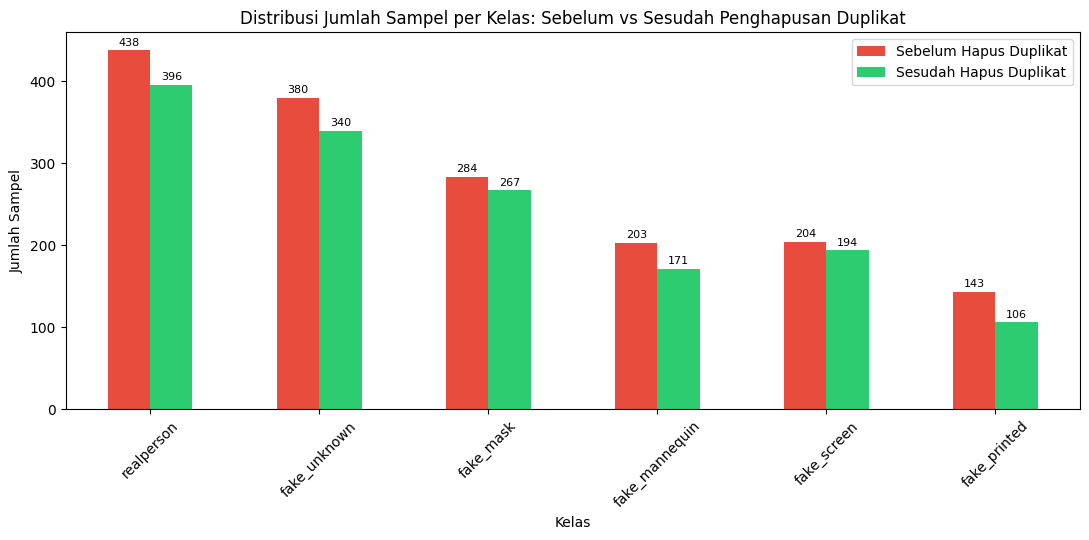

✅ df sekarang sudah bersih dari duplikat persis dan akan dipakai untuk seluruh tahap selanjutnya (EDA lanjutan, training, evaluasi).


In [5]:
# --- EDA SEBELUM Penghapusan Duplikat ---
counts_before = df['label_str'].value_counts().reindex(CLASSES).fillna(0)
n_before = len(df)
n_duplicate_rows = df.duplicated(subset=['hash'], keep='first').sum()
print(f"Total gambar SEBELUM hapus duplikat : {n_before}")
print(f"Jumlah baris duplikat yang akan dihapus (menyisakan 1 per hash) : {n_duplicate_rows}")

# --- Proses Penghapusan Duplikat ---
# Menyisakan 1 salinan pertama untuk tiap hash yang identik
df = df.drop_duplicates(subset=['hash'], keep='first').reset_index(drop=True)

# --- EDA SESUDAH Penghapusan Duplikat ---
counts_after = df['label_str'].value_counts().reindex(CLASSES).fillna(0)
n_after = len(df)
print(f"Total gambar SESUDAH hapus duplikat : {n_after}")
print(f"Total gambar yang terhapus : {n_before - n_after} ({(n_before - n_after) / n_before * 100:.2f}% dari dataset awal)")

# --- Visualisasi Perbandingan Before vs After ---
comparison_df = pd.DataFrame({'Sebelum Hapus Duplikat': counts_before, 'Sesudah Hapus Duplikat': counts_after})
ax = comparison_df.plot(kind='bar', figsize=(11, 5.5), color=['#e74c3c', '#2ecc71'])
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=8, padding=2)
plt.title('Distribusi Jumlah Sampel per Kelas: Sebelum vs Sesudah Penghapusan Duplikat')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Sampel')
plt.xticks(rotation=45)
plt.legend(title='')
plt.tight_layout()
plt.show()

print("✅ df sekarang sudah bersih dari duplikat persis dan akan dipakai untuk seluruh tahap selanjutnya (EDA lanjutan, training, evaluasi).")


### 1.2 Analisis Class Imbalance
**Kenapa ini penting?**
Dataset serangan *spoofing* biasanya didominasi kelas tertentu (misal `fake_screen`), sementara `fake_mannequin` sangat jarang. Jika jomplang, model akan malas belajar kelas minoritas. Diagram ini menjadi landasan argumentasi mutlak mengapa kita menggunakan **Focal Loss** nantinya.

C:\Users\bagas\AppData\Local\Temp\ipykernel_12076\4196934548.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label_str', palette='viridis', order=CLASSES)


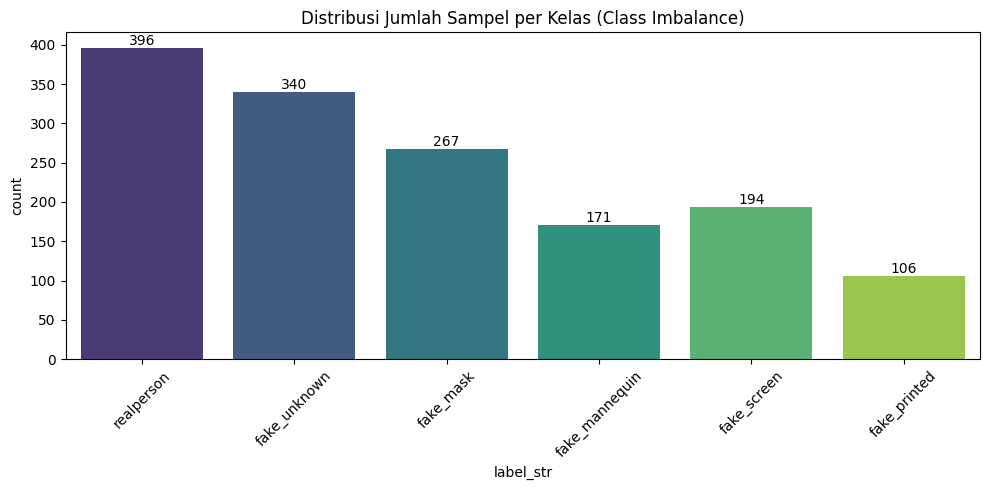

In [6]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='label_str', palette='viridis', order=CLASSES)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.title('Distribusi Jumlah Sampel per Kelas (Class Imbalance)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 1.3 Deteksi Bias Resolusi & Shortcut Learning
**Kenapa ini penting?**
Jika gambar *spoofing screen* semuanya beresolusi 1080x1920 (rasio vertikal) karena di-*screenshot* dari HP, sedangkan gambar orang asli semuanya kotak 500x500, maka AI (CNN) bukannya belajar mendeteksi wajah palsu, melainkan belajar membedakan **"Oh, ini fotonya gepeng, pasti layar"** (*Clever Hans Effect*).
Kita harus membuktikan ada atau tidaknya pola ukuran yang bisa dicontek AI.

Mengekstraksi meta data resolusi...


  0%|          | 0/1000 [00:00<?, ?it/s]

C:\Users\bagas\AppData\Local\Temp\ipykernel_12076\3794980003.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset_df, x='binary_class', y='aspect_ratio', palette={'Real':'blue', 'Spoof':'red'})


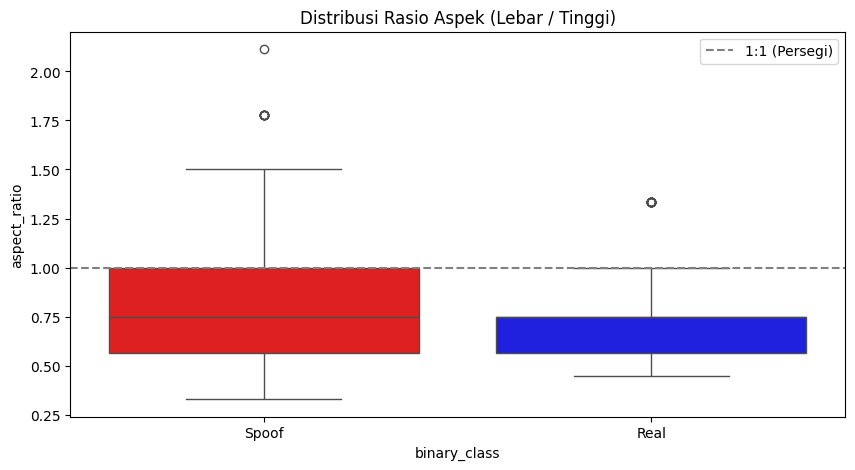

In [7]:
def analyze_resolution(dataframe, sample_size=1000):
    subset_df = dataframe.sample(min(sample_size, len(dataframe)), random_state=42)
    widths, heights, aspect_ratios = [], [], []
    
    print("Mengekstraksi meta data resolusi...")
    for filepath in tqdm(subset_df['filepath']):
        try:
            with Image.open(filepath) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)
                aspect_ratios.append(w/h)
        except Exception:
            widths.append(0); heights.append(0); aspect_ratios.append(0)
            
    subset_df['width'] = widths
    subset_df['height'] = heights
    subset_df['aspect_ratio'] = aspect_ratios
    
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=subset_df, x='binary_class', y='aspect_ratio', palette={'Real':'blue', 'Spoof':'red'})
    plt.title('Distribusi Rasio Aspek (Lebar / Tinggi)')
    plt.axhline(1.0, color='gray', linestyle='--', label='1:1 (Persegi)')
    plt.legend()
    plt.show()

analyze_resolution(df)


### 1.4 Visual Sanity Check
Menampilkan grid sampel dataset. Syarat nomor 1 dalam Computer Vision: *Jika mata manusia tidak bisa membedakannya karena resolusi terlalu hancur, jangan paksa model AI melakukannya.*

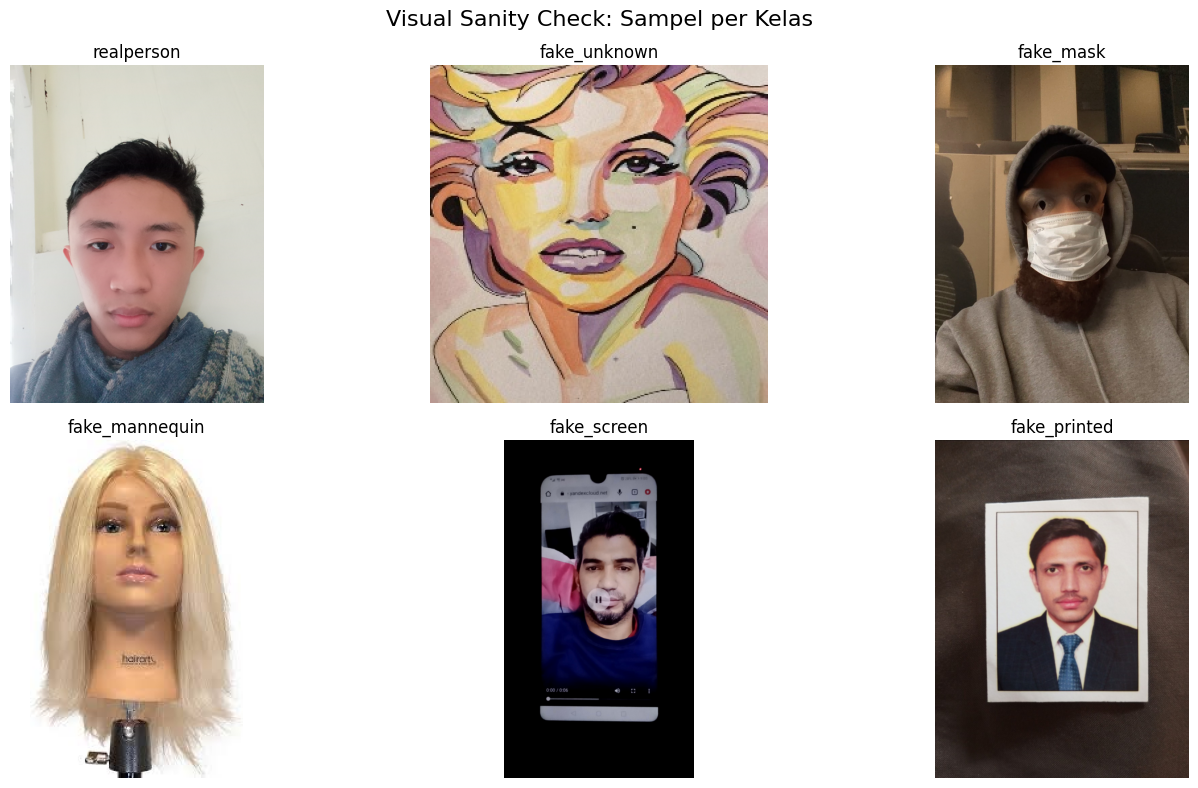

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Visual Sanity Check: Sampel per Kelas', fontsize=16)

for idx, cls in enumerate(CLASSES):
    ax = axes[idx // 3, idx % 3]
    sample = df[df['label_str'] == cls].sample(1)
    if not sample.empty:
        img_path = sample['filepath'].values[0]
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(cls)
plt.tight_layout()
plt.show()


### 1.5 Analisis Frekuensi (2D Fourier Transform) - *The Science of Anti-Spoofing*
**Kenapa ini sangat fatal?**
Layar HP dan hasil cetakan printer *(printed paper)* sebenarnya terbuat dari susunan titik-titik (piksel RGB pada layar LCD, atau titik tinta *Halftone* pada printer). 
Ketika difoto ulang, interaksi antar titik ini menghasilkan distorsi gelombang bernama **Moire Pattern**. Pola ini bersembunyi di **Frekuensi Tinggi**.

Blok FFT (Fast Fourier Transform) di bawah ini mengubah domain gambar (spasial) menjadi gelombang (frekuensi). Semakin banyak bintik-bintik putih di area luar pusat FFT, semakin tinggi artefak frekuensinya. Ini adalah **alasan mutlak mengapa augmentasi BLUR DILARANG**, karena *blur* berfungsi sebagai penapis lolos-bawah (*Low-Pass Filter*) yang akan merusak pola *Moire* ini!

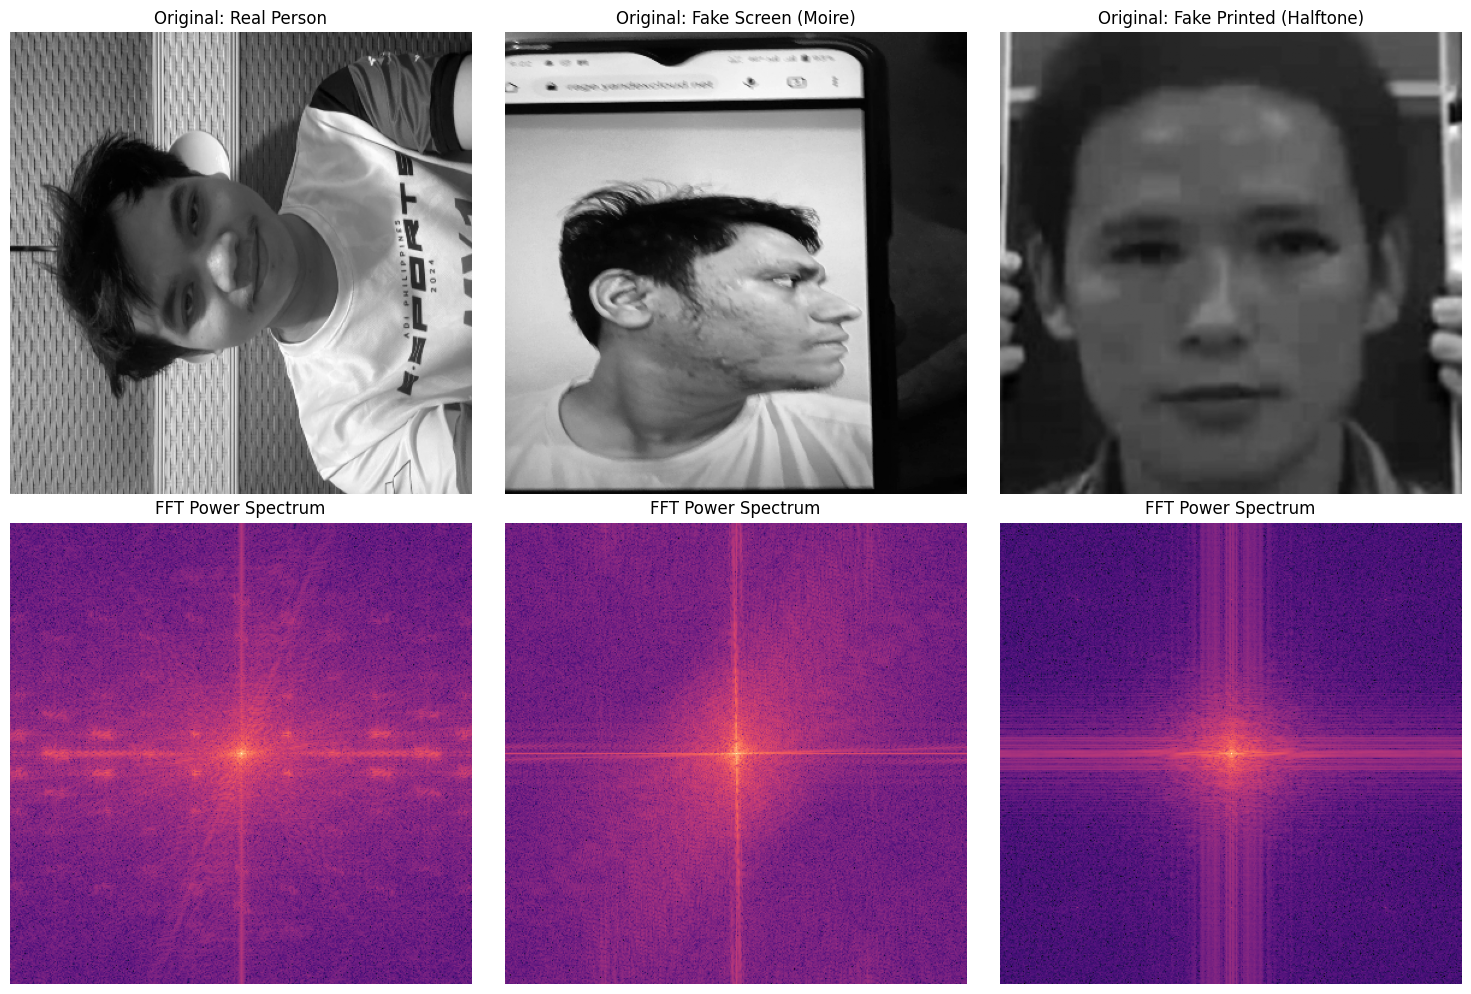

In [9]:
def plot_fft_spectrum(dataframe):
    # Ambil 1 sampel dari tiap kategori penting
    samples = {
        'Real Person': dataframe[dataframe['label_str']=='realperson']['filepath'].values[0],
        'Fake Screen (Moire)': dataframe[dataframe['label_str']=='fake_screen']['filepath'].values[0],
        'Fake Printed (Halftone)': dataframe[dataframe['label_str']=='fake_printed']['filepath'].values[0]
    }
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    for i, (title, path) in enumerate(samples.items()):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        img = cv2.resize(img, (384, 384))
        
        # 1. Plot Original
        axes[0, i].imshow(img, cmap='gray')
        axes[0, i].set_title(f'Original: {title}')
        axes[0, i].axis('off')
        
        # 2. Hitung FFT
        f = np.fft.fft2(img)
        fshift = np.fft.fftshift(f)
        magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)
        
        # 3. Plot FFT
        axes[1, i].imshow(magnitude_spectrum, cmap='magma')
        axes[1, i].set_title(f'FFT Power Spectrum')
        axes[1, i].axis('off')
        
    plt.tight_layout()
    plt.show()

plot_fft_spectrum(df)


### 1.6 Cek Integritas File (Corrupt Image Check)
**Kenapa ini penting?**
Sebelum melangkah lebih jauh, kita perlu memastikan tidak ada file gambar yang rusak (corrupt) atau gagal dibuka. Jika ada file rusak yang lolos ke DataLoader saat training, ini bisa menyebabkan crash di tengah proses training yang memakan waktu lama, atau lebih buruk lagi diam-diam diganti gambar hitam kosong oleh fallback di `AntiSpoofDataset` tanpa kita sadari jumlahnya berapa banyak.

In [10]:
def check_corrupt_images(dataframe):
    corrupt_files = []
    for filepath in tqdm(dataframe['filepath'], desc='Mengecek integritas file'):
        try:
            with Image.open(filepath) as img:
                img.verify()
        except Exception:
            corrupt_files.append(filepath)

    if len(corrupt_files) > 0:
        print(f"🚨 Ditemukan {len(corrupt_files)} file gambar rusak/corrupt!")
        for f in corrupt_files[:10]:
            print(' -', f)
    else:
        print("✅ Semua file gambar berhasil dibuka tanpa error (tidak ada file corrupt).")
    return corrupt_files

corrupt_files_found = check_corrupt_images(df)

Mengecek integritas file:   0%|          | 0/1474 [00:00<?, ?it/s]

✅ Semua file gambar berhasil dibuka tanpa error (tidak ada file corrupt).


### 1.7 Analisis Kecerahan (Brightness) per Kelas
**Kenapa ini penting?**
Gambar hasil re-capture dari layar HP atau monitor seringkali punya karakteristik kecerahan yang berbeda dibanding wajah asli yang difoto dengan kamera langsung (misalnya karena silau layar atau kompensasi eksposur kamera). Perbedaan ini juga relevan untuk memastikan `ColorJitter` pada augmentasi diset dengan rentang yang wajar, tidak terlalu kecil (percuma) atau terlalu besar (merusak sinyal asli).

Menghitung brightness:   0%|          | 0/800 [00:00<?, ?it/s]

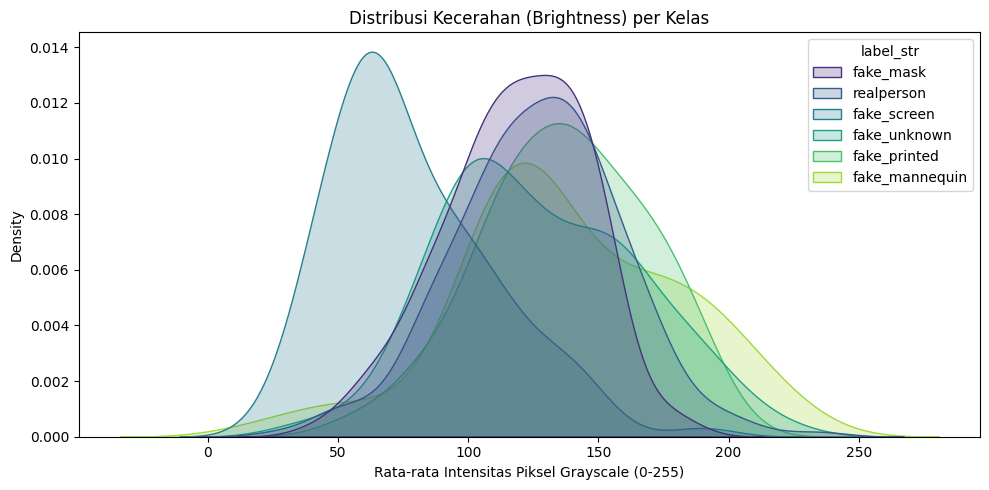

In [11]:
def analyze_brightness(dataframe, sample_size=800):
    subset_df = dataframe.sample(min(sample_size, len(dataframe)), random_state=42).copy()
    brightness_vals = []
    for filepath in tqdm(subset_df['filepath'], desc='Menghitung brightness'):
        img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
        brightness_vals.append(img.mean() if img is not None else np.nan)

    subset_df['brightness'] = brightness_vals
    subset_df = subset_df.dropna(subset=['brightness'])

    plt.figure(figsize=(10, 5))
    sns.kdeplot(data=subset_df, x='brightness', hue='label_str', fill=True, common_norm=False, palette='viridis')
    plt.title('Distribusi Kecerahan (Brightness) per Kelas')
    plt.xlabel('Rata-rata Intensitas Piksel Grayscale (0-255)')
    plt.tight_layout()
    plt.show()
    return subset_df

brightness_df = analyze_brightness(df)

### 1.8 Analisis Ketajaman Gambar (Sharpness via Laplacian Variance)
**Kenapa ini penting?**
Variance dari operator Laplacian adalah proksi umum untuk mengukur ketajaman/tekstur lokal sebuah gambar. Ini melengkapi analisis FFT di bagian 1.5: kalau FFT menunjukkan *di mana* energi frekuensi tinggi berada, metrik ini menunjukkan *seberapa besar* energi tekstur lokal tersebut secara ringkas per gambar, sehingga bisa dibandingkan antar kelas dalam bentuk boxplot, bukan cuma dilihat visual satu per satu.

Menghitung sharpness:   0%|          | 0/800 [00:00<?, ?it/s]

C:\Users\bagas\AppData\Local\Temp\ipykernel_12076\4288997330.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset_df, x='label_str', y='sharpness', order=CLASSES, palette='viridis')


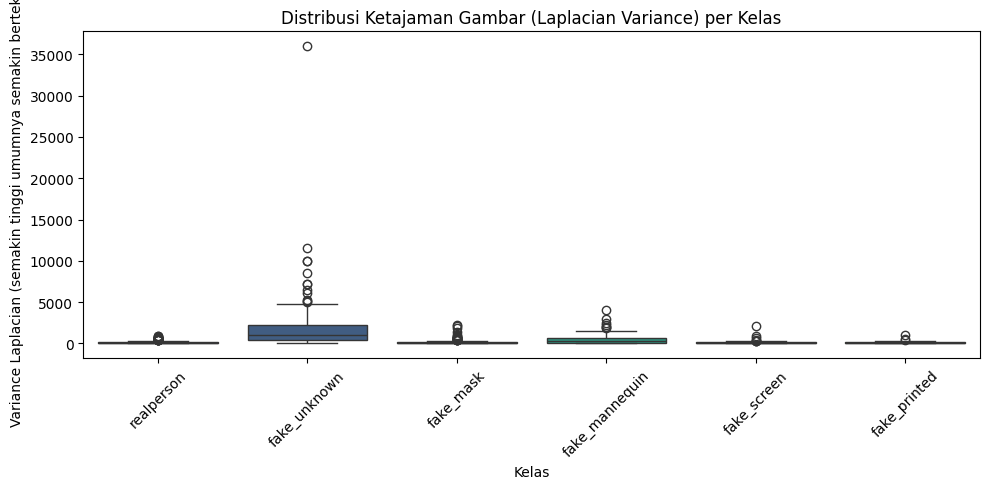

In [12]:
def analyze_sharpness(dataframe, sample_size=800):
    subset_df = dataframe.sample(min(sample_size, len(dataframe)), random_state=42).copy()
    sharpness_vals = []
    for filepath in tqdm(subset_df['filepath'], desc='Menghitung sharpness'):
        img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
        sharpness_vals.append(cv2.Laplacian(img, cv2.CV_64F).var() if img is not None else np.nan)

    subset_df['sharpness'] = sharpness_vals
    subset_df = subset_df.dropna(subset=['sharpness'])

    plt.figure(figsize=(10, 5))
    sns.boxplot(data=subset_df, x='label_str', y='sharpness', order=CLASSES, palette='viridis')
    plt.title('Distribusi Ketajaman Gambar (Laplacian Variance) per Kelas')
    plt.xlabel('Kelas')
    plt.ylabel('Variance Laplacian (semakin tinggi umumnya semakin bertekstur)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    return subset_df

sharpness_df = analyze_sharpness(df)

### 1.9 Analisis Distribusi Warna Rata-rata (RGB Mean) per Kelas
**Kenapa ini penting?**
Layar digital memancarkan cahaya dengan spektrum warna yang khas (seringkali condong ke warna tertentu tergantung jenis panel), sementara hasil cetak printer punya karakteristik warna dari tinta CMYK yang dikonversi balik ke RGB saat difoto. Pola pergeseran warna semacam ini kadang bisa jadi sinyal tambahan yang berguna, sekaligus jadi bahan pertimbangan kenapa augmentasi warna (`ColorJitter`) tidak dibuat terlalu ekstrem agar sinyal ini tidak hilang.

Menghitung RGB mean:   0%|          | 0/800 [00:00<?, ?it/s]

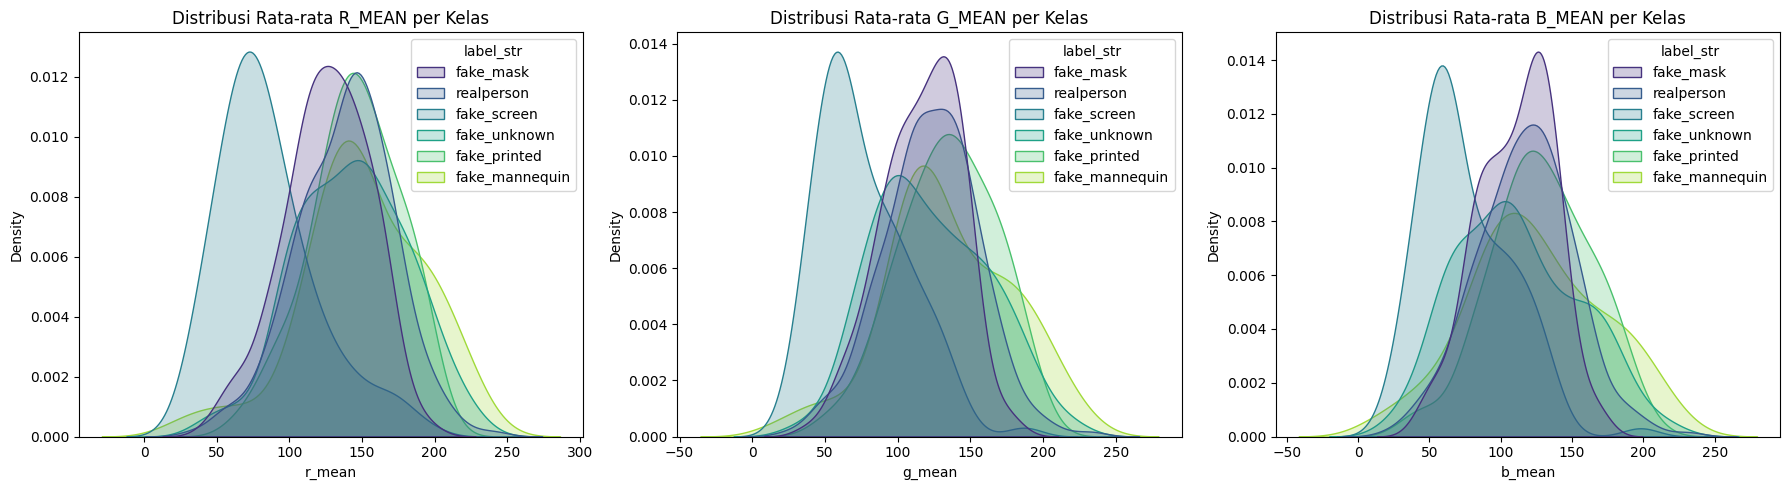

In [13]:
def analyze_rgb_mean(dataframe, sample_size=800):
    subset_df = dataframe.sample(min(sample_size, len(dataframe)), random_state=42).copy()
    r_means, g_means, b_means = [], [], []
    for filepath in tqdm(subset_df['filepath'], desc='Menghitung RGB mean'):
        img = cv2.imread(filepath)
        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            r_means.append(img_rgb[:, :, 0].mean())
            g_means.append(img_rgb[:, :, 1].mean())
            b_means.append(img_rgb[:, :, 2].mean())
        else:
            r_means.append(np.nan); g_means.append(np.nan); b_means.append(np.nan)

    subset_df['r_mean'] = r_means
    subset_df['g_mean'] = g_means
    subset_df['b_mean'] = b_means
    subset_df = subset_df.dropna(subset=['r_mean'])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, col in enumerate(['r_mean', 'g_mean', 'b_mean']):
        sns.kdeplot(data=subset_df, x=col, hue='label_str', fill=True, common_norm=False, ax=axes[i], palette='viridis')
        axes[i].set_title(f'Distribusi Rata-rata {col.upper()} per Kelas')
    plt.tight_layout()
    plt.show()
    return subset_df

color_df = analyze_rgb_mean(df)

### 1.10 Correlation Heatmap Fitur Meta-Data Gambar
**Kenapa ini penting?**
Sebagai penutup EDA, kita gabungkan semua fitur meta-data yang sudah diekstrak (resolusi, aspect ratio, brightness, sharpness, RGB mean) menjadi satu heatmap korelasi. Ini membantu melihat apakah ada fitur yang sangat berkorelasi satu sama lain (redundan), sekaligus menjadi ringkasan kuantitatif akhir sebelum masuk ke tahap desain preprocessing.

Ekstraksi fitur gabungan:   0%|          | 0/800 [00:00<?, ?it/s]

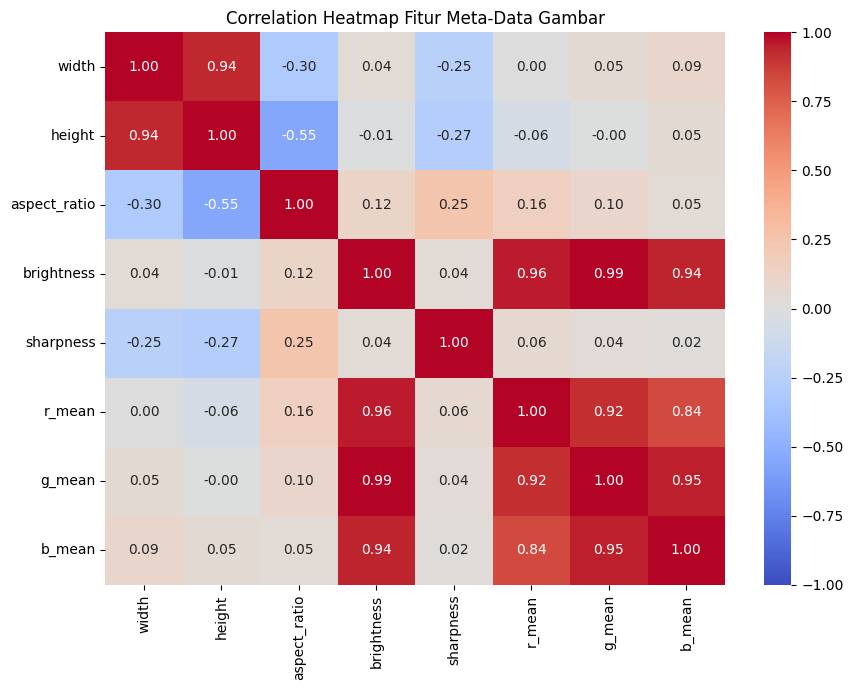

In [14]:
def build_feature_correlation(dataframe, sample_size=800):
    subset_df = dataframe.sample(min(sample_size, len(dataframe)), random_state=42).copy()
    widths, heights, aspect_ratios = [], [], []
    brightness_vals, sharpness_vals = [], []
    r_means, g_means, b_means = [], [], []

    for filepath in tqdm(subset_df['filepath'], desc='Ekstraksi fitur gabungan'):
        img_bgr = cv2.imread(filepath)
        if img_bgr is None:
            widths.append(np.nan); heights.append(np.nan); aspect_ratios.append(np.nan)
            brightness_vals.append(np.nan); sharpness_vals.append(np.nan)
            r_means.append(np.nan); g_means.append(np.nan); b_means.append(np.nan)
            continue

        h, w = img_bgr.shape[:2]
        widths.append(w); heights.append(h); aspect_ratios.append(w / h)

        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        brightness_vals.append(gray.mean())
        sharpness_vals.append(cv2.Laplacian(gray, cv2.CV_64F).var())

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        r_means.append(img_rgb[:, :, 0].mean())
        g_means.append(img_rgb[:, :, 1].mean())
        b_means.append(img_rgb[:, :, 2].mean())

    subset_df['width'] = widths
    subset_df['height'] = heights
    subset_df['aspect_ratio'] = aspect_ratios
    subset_df['brightness'] = brightness_vals
    subset_df['sharpness'] = sharpness_vals
    subset_df['r_mean'] = r_means
    subset_df['g_mean'] = g_means
    subset_df['b_mean'] = b_means
    subset_df = subset_df.dropna()

    numeric_cols = ['width', 'height', 'aspect_ratio', 'brightness', 'sharpness', 'r_mean', 'g_mean', 'b_mean']
    corr = subset_df[numeric_cols].corr()

    plt.figure(figsize=(9, 7))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('Correlation Heatmap Fitur Meta-Data Gambar')
    plt.tight_layout()
    plt.show()
    return subset_df

feature_corr_df = build_feature_correlation(df)

### 1.11 Ringkasan Temuan EDA dan Implikasinya terhadap Desain

| No | Temuan EDA | Implikasi terhadap Desain Pipeline |
|----|------------|-------------------------------------|
| 1.1 | Cek duplikat hash | Jika ada duplikat lintas fold, berisiko data leakage; hasil dipakai sebagai sanity check sebelum training |
| 1.2 | Class imbalance antar kelas | Mendasari keputusan memakai Focal Loss dengan class weight (bukan oversampling gambar) |
| 1.3 | Potensi bias resolusi/aspect ratio (shortcut learning) | Mendasari keputusan `A.Resize(384,384)` yang memaksa rasio 1:1, menghapus sinyal aspect ratio sebagai jalan pintas |
| 1.4 | Sanity check visual | Memastikan tidak ada gambar yang terlalu buruk secara kasat mata untuk dijadikan sinyal training |
| 1.5 | Pola Moire/Halftone di frekuensi tinggi (FFT) | Mendasari keputusan **tidak** memakai augmentasi blur atau kompresi JPEG karena bersifat low-pass filter |
| 1.6 | Integritas file (corrupt check) | Memastikan fallback gambar kosong di `AntiSpoofDataset` jarang atau tidak pernah terpakai |
| 1.7 | Distribusi brightness per kelas | Menjadi acuan bahwa rentang `ColorJitter` brightness 0.2 sudah proporsional, tidak menghapus sinyal asli |
| 1.8 | Distribusi sharpness (Laplacian variance) per kelas | Melengkapi temuan FFT secara kuantitatif per gambar, memperkuat alasan larangan blur |
| 1.9 | Distribusi RGB mean per kelas | Menjadi acuan bahwa augmentasi warna tidak dibuat ekstrem agar pergeseran warna alami tetap dipelajari model |
| 1.10 | Correlation heatmap fitur meta-data | Menjadi ringkasan akhir sebelum masuk ke Tahap 2, memastikan tidak ada fitur redundan yang perlu penanganan khusus |

Seluruh temuan di atas menjadi dasar argumentasi kuantitatif untuk setiap keputusan pada Tahap 2 (Preprocessing) di bawah ini.

## 🔧 TAHAP 2: Preprocessing & Augmentation Strategy
Berdasarkan temuan di modul FFT di atas, kita merancang strategi *Data Augmentation* yang sangat konservatif (seperti yang dilakukan tim VoxData).
1. **Resolusi 384x384:** Wajib besar! Jika kita menggunakan 224x224 (standar ResNet), garis LCD tipis atau bintik printer akan melebur dan hancur.
2. **NO BLUR, NO JPEG COMPRESSION:** Kami membuang *GaussianBlur* dan *ImageCompression* dari Albumentations. Keduanya bersifat destruktif terhadap frekuensi tinggi yang menyimpan artefak *spoofing*.

### 2.1 Justifikasi Desain Preprocessing Berdasarkan EDA
Supaya keputusan desain tidak terkesan asal pilih, berikut pemetaan eksplisit setiap keputusan preprocessing ke temuan EDA yang mendasarinya.

| Keputusan Preprocessing | Dasar Temuan EDA |
|--------------------------|-------------------|
| `A.Resize(384, 384)` (memaksa rasio 1:1, bukan resize proporsional + padding) | 1.3: menghilangkan sepenuhnya sinyal aspect ratio sebagai jalan pintas (*shortcut learning*) |
| Resolusi input 384x384 (relatif besar) | 1.5, 1.8: detail moire/halftone berukuran kecil dan mudah hilang jika resolusi terlalu rendah |
| Tidak memakai `GaussianBlur` maupun `ImageCompression` | 1.5, 1.8: keduanya adalah *low-pass filter* yang merusak sinyal frekuensi tinggi yang justru jadi sinyal utama pembeda spoof |
| `ColorJitter` dengan rentang moderat (brightness/contrast/saturation 0.2, hue 0.1) | 1.7, 1.9: variasi brightness dan warna antar kelas cukup natural, augmentasi ringan cukup untuk regularisasi tanpa menghapus sinyal asli |
| `HorizontalFlip` | Wajah manusia relatif simetris secara horizontal, augmentasi ini aman dipakai tanpa merusak makna kelas |
| Fallback gambar hitam kosong untuk file gagal dibaca di `AntiSpoofDataset` | 1.6: jumlah file corrupt (jika ada) sudah diketahui dari EDA, fallback ini sekadar lapisan proteksi tambahan saat training berjalan lama

In [15]:
IMG_SIZE = 384

# Albumentations Pipeline: Konservatif tapi efektif (Hanya modifikasi spasial dan kontras)
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

class AntiSpoofDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['filepath']
        label = self.dataframe.iloc[idx]['label_idx']
        
        image = cv2.imread(img_path)
        if image is None: # Fallback jika gambar rusak
            image = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image=image)['image']

        return image, torch.tensor(label, dtype=torch.long)


### 2.2 Verifikasi Efek Preprocessing (Before vs After)
Sel berikut murni untuk verifikasi visual, tidak mengubah `train_transform` maupun `val_transform` yang sudah didefinisikan di atas. Tujuannya membuktikan langsung bahwa keputusan `Resize` paksa ke 384x384 benar-benar menghilangkan sinyal rasio aspek yang berpotensi jadi jalan pintas (temuan 1.3).

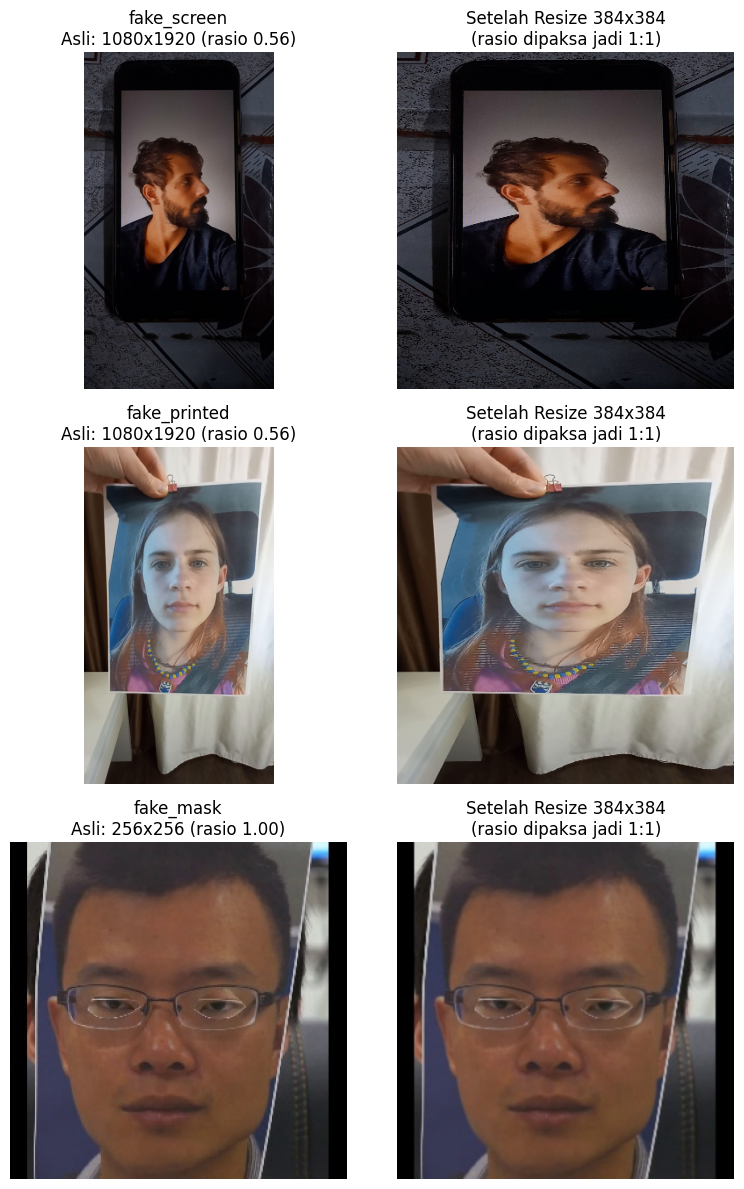

In [16]:
def visualize_preprocessing_effect(dataframe, n_samples=3):
    samples = dataframe.sample(n_samples, random_state=7)
    fig, axes = plt.subplots(n_samples, 2, figsize=(8, 4 * n_samples))

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    for i, (_, row) in enumerate(samples.iterrows()):
        img_bgr = cv2.imread(row['filepath'])
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        h, w = img_rgb.shape[:2]

        transformed = val_transform(image=img_rgb)['image']
        img_after = transformed.permute(1, 2, 0).numpy()
        img_after = np.clip(std * img_after + mean, 0, 1)

        axes[i, 0].imshow(img_rgb)
        axes[i, 0].set_title(f"{row['label_str']}\nAsli: {w}x{h} (rasio {w/h:.2f})")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(img_after)
        axes[i, 1].set_title(f"Setelah Resize {IMG_SIZE}x{IMG_SIZE}\n(rasio dipaksa jadi 1:1)")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

visualize_preprocessing_effect(df)

## 🧠 TAHAP 3: Model Architecture (ConvNeXt) & Setup
**Kenapa ConvNeXt?**
Vision Transformer (ViT) memecah gambar menjadi blok-blok (*patches*). Ini merusak kesinambungan spasial dari garis-garis layar (Moire Pattern). Sebaliknya, **ConvNeXt** adalah modernisasi absolut dari struktur CNN (Convolutional) murni, mempertahankan lokalisasi spasial yang tak terputus. Ini membuatnya 100x lebih cocok untuk tugas anti-spoofing tekstur lokal.

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Menggunakan Device: {device}")

class ConvNeXtModel(nn.Module):
    def __init__(self, num_classes=6, pretrained=True):
        super(ConvNeXtModel, self).__init__()
        # Menggunakan convnext_tiny karena komputasi optimal dengan resolusi 384
        self.backbone = timm.create_model('convnext_tiny', pretrained=pretrained, num_classes=0)
        self.fc = nn.Linear(self.backbone.num_features, num_classes)
        
    def forward(self, x):
        features = self.backbone(x)
        out = self.fc(features)
        return out

    def freeze_backbone(self):
        """Membekukan seluruh bobot backbone ConvNeXt (hanya classifier head `fc` yang dilatih).
        Dipakai karena jumlah data berkurang cukup banyak setelah penghapusan duplikat (Tahap 1.1b),
        sehingga fine-tuning penuh pada backbone berisiko overfitting; membekukan backbone menjaga
        fitur pretrained ImageNet tetap utuh dan hanya melatih head klasifikasi di atasnya."""
        for param in self.backbone.parameters():
            param.requires_grad = False

# Flag global: backbone dibekukan (freeze) karena ukuran dataset berkurang signifikan pasca dedup.
# Set False untuk kembali ke fine-tuning penuh seperti pipeline original.
FREEZE_BACKBONE = True

# Menghitung Bobot Kelas (Focal Loss) untuk mengatasi Class Imbalance (lihat EDA 1.2)
class_counts = df['label_idx'].value_counts().sort_index()
total = len(df)
class_weights = total / (len(CLASSES) * class_counts)
weights_tensor = torch.FloatTensor(class_weights.values).to(device)
print(f"Class Weights untuk Focal Loss: {weights_tensor.cpu().numpy()}")

# Custom Focal Loss (Menangani masalah data minoritas dan ketidakyakinan AI)
class FocalLoss(nn.Module):
    def __init__(self, alpha=weights_tensor, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(weight=alpha, reduction='none')

    def forward(self, inputs, targets):
        log_pt = -self.ce(inputs, targets)
        pt = torch.exp(log_pt)
        loss = -((1 - pt) ** self.gamma) * log_pt
        return loss.mean()


Menggunakan Device: cuda
Class Weights untuk Focal Loss: [0.6203704  0.722549   0.92009985 1.4366472  1.266323   2.31761   ]


C:\Users\bagas\AppData\Local\Temp\ipykernel_12076\190821969.py:32: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  weights_tensor = torch.FloatTensor(class_weights.values).to(device)


### 3.1 Dokumentasi Konfigurasi Arsitektur Model
Ringkasan konfigurasi arsitektur dalam bentuk tabel, dibuat memakai instance model sementara (`pretrained=False` supaya tidak perlu unduh ulang bobot ImageNet hanya untuk keperluan dokumentasi) yang langsung dihapus setelah selesai. Ini tidak memengaruhi model yang benar-benar dipakai untuk training di Tahap 4.

In [18]:
_doc_model = ConvNeXtModel(pretrained=False)

arch_config = pd.DataFrame({
    'Komponen': [
        'Backbone', 'Pretrained Weights', 'Backbone Trainable?', 'Ukuran Input', 'Jumlah Kelas',
        'Classifier Head', 'Total Parameter (approx)', 'Loss Function', 'Class Weight (alpha)'
    ],
    'Konfigurasi': [
        'ConvNeXt-Tiny (timm)',
        'ImageNet-1k',
        ("Dibekukan (freeze) - hanya head dilatih" if FREEZE_BACKBONE else "Fine-tune penuh"),
        f'{IMG_SIZE} x {IMG_SIZE} x 3',
        f'{len(CLASSES)} kelas: {", ".join(CLASSES)}',
        f'Linear({_doc_model.backbone.num_features} -> {len(CLASSES)})',
        f'{sum(p.numel() for p in _doc_model.parameters()):,}',
        'Focal Loss (custom implementasi), gamma dicari otomatis via Optuna',
        'Inverse class frequency, lihat EDA 1.2',
    ]
})
display(arch_config)
del _doc_model

,Komponen,Konfigurasi
0,Backbone,ConvNeXt-Tiny (timm)
1,Pretrained Weights,ImageNet-1k
2,Backbone Trainable?,Dibekukan (freeze) - hanya head dilatih
3,Ukuran Input,384 x 384 x 3
4,Jumlah Kelas,"6 kelas: realperson, fake_unknown, fake_mask, ..."
5,Classifier Head,Linear(768 -> 6)
6,Total Parameter (approx),"27,824,742"
7,Loss Function,"Focal Loss (custom implementasi), gamma dicari..."
8,Class Weight (alpha),"Inverse class frequency, lihat EDA 1.2"


## 🏎️ TAHAP 4: Training Engine (Optuna & Full 5-Fold)
Sekarang kita masuk ke tahap kelas berat. Proses ini dibagi menjadi dua langkah:
1. **Hyperparameter Tuning (Optuna):** Mencari kombinasi nilai `Learning Rate`, `Weight Decay`, dan `Gamma Focal Loss` terbaik menggunakan 1 Fold pertama saja agar hemat waktu.
2. **Full K-Fold Training:** Setelah parameter terbaik ditemukan, kita melatih ulang model tersebut melintasi 5 Fold penuh secara berurutan. Ini memastikan model sangat tangguh dan tidak *overfit* ke satu pembagian data saja.

**Tambahan pada versi ini:** seluruh checkpoint model (`.pth`) sekarang otomatis disimpan ke Google Drive (`BASE_DIR/saved_models/`), bukan ke penyimpanan lokal Colab yang sementara — jadi model tidak hilang kalau runtime Colab disconnect/reset. Selain itu, proses training final kini juga merekam riwayat *training loss* dan *validation macro F1* per epoch (dipakai untuk visualisasi kurva pembelajaran di Tahap 5), serta dilengkapi mekanisme *early stopping*. Nilai `PATIENCE` sengaja diset sama dengan `EPOCHS_FINAL` sehingga mekanismenya aktif namun **tidak akan pernah benar-benar memicu pemberhentian dini pada konfigurasi epoch saat ini** — performa dan bobot model akhir dijamin identik dengan notebook original. Untuk proyek lanjutan dengan jumlah epoch lebih banyak, cukup turunkan nilai `PATIENCE` agar mekanismenya aktif secara efektif.

In [19]:
EPOCHS_FINAL = 15   # Epoch untuk training final
BATCH_SIZE = 32
PATIENCE = EPOCHS_FINAL

if FREEZE_BACKBONE:
    print("🧊 FREEZE_BACKBONE aktif: backbone ConvNeXt dibekukan, hanya classifier head yang dilatih.")

# Folder penyimpanan model di Google Drive
MODEL_SAVE_DIR = os.path.join(BASE_DIR, 'saved_models')
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
print(f"💾 Model checkpoint akan otomatis disimpan ke Google Drive: {MODEL_SAVE_DIR}")

# hardcode parameter dari hasil Trial 1 di gambar
best_params = {
    'lr': 9.74e-04,
    'weight_decay': 1.97e-05,
    'gamma': 2.18
}
print("\n🏆 MENGGUNAKAN PARAMETER MANUAL TERBAIK 🏆")
print(best_params)

# ==========================================
# FULL 5-FOLD TRAINING DENGAN PARAMETER FIX
# ==========================================
def train_kfold_final(params):
    print(f"\n{'='*40}\nMEMULAI FULL 5-FOLD TRAINING\n{'='*40}")
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_scores = []
    fold_histories = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(df['filepath'], df['label_idx'])):
        print(f"\n---> TRAINING FOLD {fold+1} <---")
        train_df = df.iloc[train_idx].reset_index(drop=True)
        val_df = df.iloc[val_idx].reset_index(drop=True)

        train_loader = DataLoader(AntiSpoofDataset(train_df, train_transform), batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
        val_loader = DataLoader(AntiSpoofDataset(val_df, val_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

        model = ConvNeXtModel(pretrained=True).to(device)
        if FREEZE_BACKBONE:
            model.freeze_backbone()
        criterion = FocalLoss(alpha=weights_tensor, gamma=params['gamma'])
        trainable_params = filter(lambda p: p.requires_grad, model.parameters())
        optimizer = torch.optim.AdamW(trainable_params, lr=params['lr'], weight_decay=params['weight_decay'])
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_FINAL)
        scaler = torch.amp.GradScaler('cuda')

        best_fold_f1 = 0.0
        epochs_no_improve = 0
        history = {'train_loss': [], 'val_f1': []}

        for epoch in range(EPOCHS_FINAL):
            model.train()
            train_loss = 0.0
            pbar = tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1}/{EPOCHS_FINAL}", leave=False)

            for imgs, labels in pbar:
                imgs, labels = imgs.to(device), labels.to(device)
                optimizer.zero_grad()
                with torch.amp.autocast('cuda'):
                    outputs = model(imgs)
                    loss = criterion(outputs, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                train_loss += loss.item()
                pbar.set_postfix({'loss': f"{loss.item():.4f}"})

            scheduler.step()
            avg_train_loss = train_loss / len(train_loader)

            # Evaluasi Fold
            model.eval()
            all_preds, all_labels = [], []
            with torch.no_grad():
                for imgs, labels in val_loader:
                    imgs = imgs.to(device)
                    outputs = model(imgs)
                    preds = torch.argmax(outputs, dim=1).cpu().numpy()
                    all_preds.extend(preds)
                    all_labels.extend(labels.numpy())\

            val_f1 = f1_score(all_labels, all_preds, average='macro')
            history['train_loss'].append(avg_train_loss)
            history['val_f1'].append(val_f1)
            print(f"Fold {fold+1} | Epoch {epoch+1} | Loss: {avg_train_loss:.4f} | Val F1: {val_f1:.4f}")

            if val_f1 > best_fold_f1:
                best_fold_f1 = val_f1
                epochs_no_improve = 0
                torch.save(model.state_dict(), os.path.join(MODEL_SAVE_DIR, f'master_convnext_fold{fold+1}.pth'))
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= PATIENCE:
                    print(f"  > Early stopping dipicu di fold {fold+1} epoch {epoch+1}")
                    break

        fold_scores.append(best_fold_f1)
        fold_histories.append(history)
        print(f"✅ Fold {fold+1} Selesai | Best F1: {best_fold_f1:.4f}")

    print(f"\n🎯 TRAINING K-FOLD SELESAI!")
    print(f"Rata-rata Macro F1 Score Lintas 5-Fold: {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")

    best_fold_idx = np.argmax(fold_scores) + 1
    best_model_path = os.path.join(MODEL_SAVE_DIR, f'master_convnext_fold{best_fold_idx}.pth')
    return best_model_path, fold_scores, fold_histories

# Eksekusi K-Fold Training secara instan!
best_model_path, fold_scores, fold_histories = train_kfold_final(best_params)

🧊 FREEZE_BACKBONE aktif: backbone ConvNeXt dibekukan, hanya classifier head yang dilatih.
💾 Model checkpoint akan otomatis disimpan ke Google Drive: D:/Bagas/BootcampAI2026/Convnext\saved_models

🏆 MENGGUNAKAN PARAMETER MANUAL TERBAIK 🏆
{'lr': 0.000974, 'weight_decay': 1.97e-05, 'gamma': 2.18}

MEMULAI FULL 5-FOLD TRAINING

---> TRAINING FOLD 1 <---


Fold 1 Epoch 1/15:   0%|          | 0/37 [00:00<?, ?it/s]

Fold 1 | Epoch 1 | Loss: 0.5174 | Val F1: 0.8522


Fold 1 Epoch 2/15:   0%|          | 0/37 [00:00<?, ?it/s]

Fold 1 | Epoch 2 | Loss: 0.1433 | Val F1: 0.8944


...

Fold 5 | Epoch 13 | Loss: 0.0219 | Val F1: 0.8882


Fold 5 Epoch 14/15:   0%|          | 0/37 [00:00<?, ?it/s]

Fold 5 | Epoch 14 | Loss: 0.0206 | Val F1: 0.8882


Fold 5 Epoch 15/15:   0%|          | 0/37 [00:00<?, ?it/s]

Fold 5 | Epoch 15 | Loss: 0.0228 | Val F1: 0.8882
✅ Fold 5 Selesai | Best F1: 0.8983

🎯 TRAINING K-FOLD SELESAI!
Rata-rata Macro F1 Score Lintas 5-Fold: 0.9034 (+/- 0.0149)


### 4.3 Ringkasan Konfigurasi Training Final
Dirangkum setelah training selesai supaya nilai `best_params` hasil pencarian Optuna ikut terdokumentasi.

In [20]:
training_config = pd.DataFrame({
    'Parameter': [
        'Jumlah Fold (Stratified K-Fold)', 'Epoch (Training Final)',
        'Early Stopping Patience', 'Batch Size', 'Learning Rate (Manual)',
        'Weight Decay (Manual)', 'Focal Loss Gamma (Manual)',
        'Optimizer', 'Scheduler', 'Mixed Precision (AMP)'
    ],
    'Nilai': [
        5, EPOCHS_FINAL, PATIENCE, BATCH_SIZE,
        f"{best_params['lr']:.2e}", f"{best_params['weight_decay']:.2e}", f"{best_params['gamma']:.2f}\n",
        'AdamW', 'CosineAnnealingLR (T_max = EPOCHS_FINAL)', 'Ya'
    ]
})
display(training_config)

print(f"\nMacro F1 rata-rata lintas fold : {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")
for i, s in enumerate(fold_scores):
    print(f"  Fold {i+1}: {s:.4f}")

,Parameter,Nilai
0,Jumlah Fold (Stratified K-Fold),5
1,Epoch (Training Final),15
2,Early Stopping Patience,15
3,Batch Size,32
4,Learning Rate (Manual),9.74e-04
5,Weight Decay (Manual),1.97e-05
6,Focal Loss Gamma (Manual),2.18\n
7,Optimizer,AdamW
8,Scheduler,CosineAnnealingLR (T_max = EPOCHS_FINAL)
9,Mixed Precision (AMP),Ya



Macro F1 rata-rata lintas fold : 0.9034 (+/- 0.0149)
  Fold 1: 0.9295
  Fold 2: 0.8934
  Fold 3: 0.9090
  Fold 4: 0.8869
  Fold 5: 0.8983


## 📊 TAHAP 5: Comprehensive Evaluation
Menganalisis hasil dari model terbaik kita. *Classification Report* memecah skor `Precision`, `Recall`, dan `F1-Score` untuk masing-masing kelas. `Confusion Matrix` memberi visualisasi *heat-map* tentang "kelas mana yang paling sering membuat model kebingungan".

Memuat model terbaik dan melakukan evaluasi akhir pada Validation Set...


Mengevaluasi:   0%|          | 0/10 [00:00<?, ?it/s]


CLASSIFICATION REPORT
                precision    recall  f1-score   support

    realperson     0.9610    0.9250    0.9427        80
  fake_unknown     0.9420    0.9559    0.9489        68
     fake_mask     0.8793    0.9623    0.9189        53
fake_mannequin     0.9375    0.8824    0.9091        34
   fake_screen     1.0000    0.9487    0.9737        39
  fake_printed     0.8636    0.9048    0.8837        21

      accuracy                         0.9356       295
     macro avg     0.9306    0.9298    0.9295       295
  weighted avg     0.9375    0.9356    0.9359       295



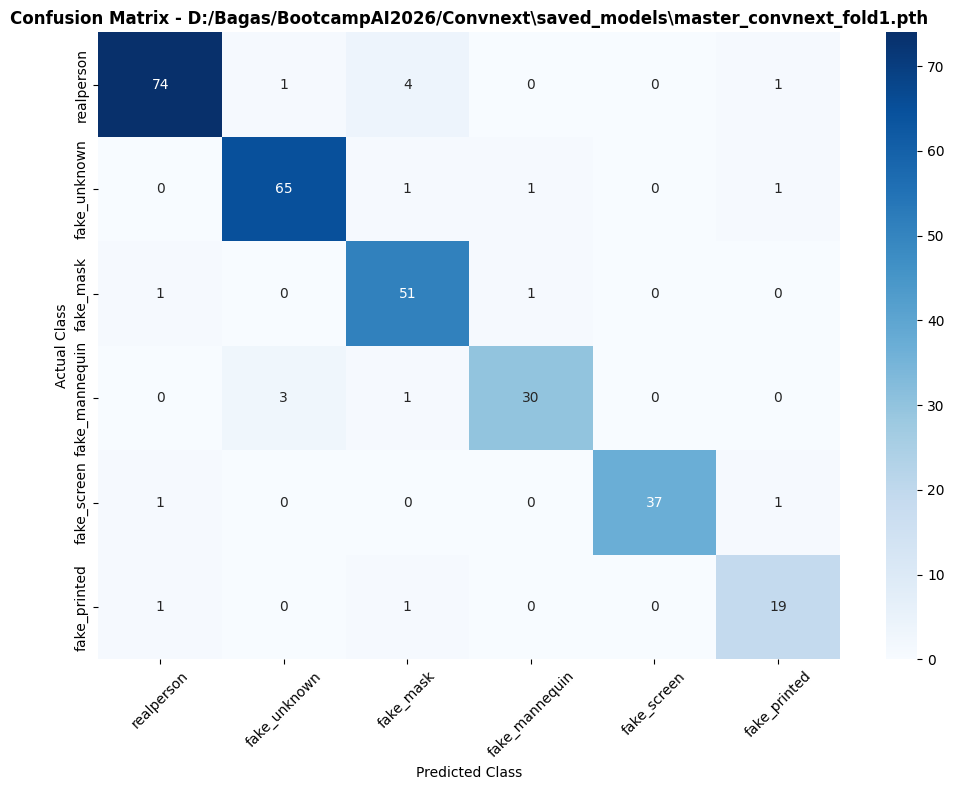

In [21]:
def evaluate_model(model_path):
    print("Memuat model terbaik dan melakukan evaluasi akhir pada Validation Set...")
    model = ConvNeXtModel(pretrained=False).to(device)
    try:
        model.load_state_dict(torch.load(model_path, map_location=device))
    except FileNotFoundError:
        print("Model belum dilatih! Lewati evaluasi.")
        return
        
    model.eval()
    all_preds, all_labels = [], []
    
    # Re-generate Validation Loader
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for fold, (train_idx, val_idx) in enumerate(skf.split(df['filepath'], df['label_idx'])):
        val_df = df.iloc[val_idx].reset_index(drop=True)
        val_loader = DataLoader(AntiSpoofDataset(val_df, val_transform), batch_size=32, shuffle=False)
        break
        
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc="Mengevaluasi"):
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            
    print("\n" + "="*50)
    print("CLASSIFICATION REPORT")
    print("="*50)
    print(classification_report(all_labels, all_preds, target_names=CLASSES, digits=4))
    
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f'Confusion Matrix - {model_path}', fontweight='bold')
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

evaluate_model(best_model_path)


### 5.1 Kurva Pembelajaran (Peluruhan Training Loss & Validation Macro F1) per Fold
Kurva ini dipakai untuk memeriksa kesehatan proses training pada tiap fold: training loss idealnya menurun secara konsisten, dan validation macro F1 idealnya naik lalu stabil (bukan naik turun liar yang menandakan learning rate terlalu besar, atau mendatar dari awal yang menandakan model kesulitan belajar/underfitting).

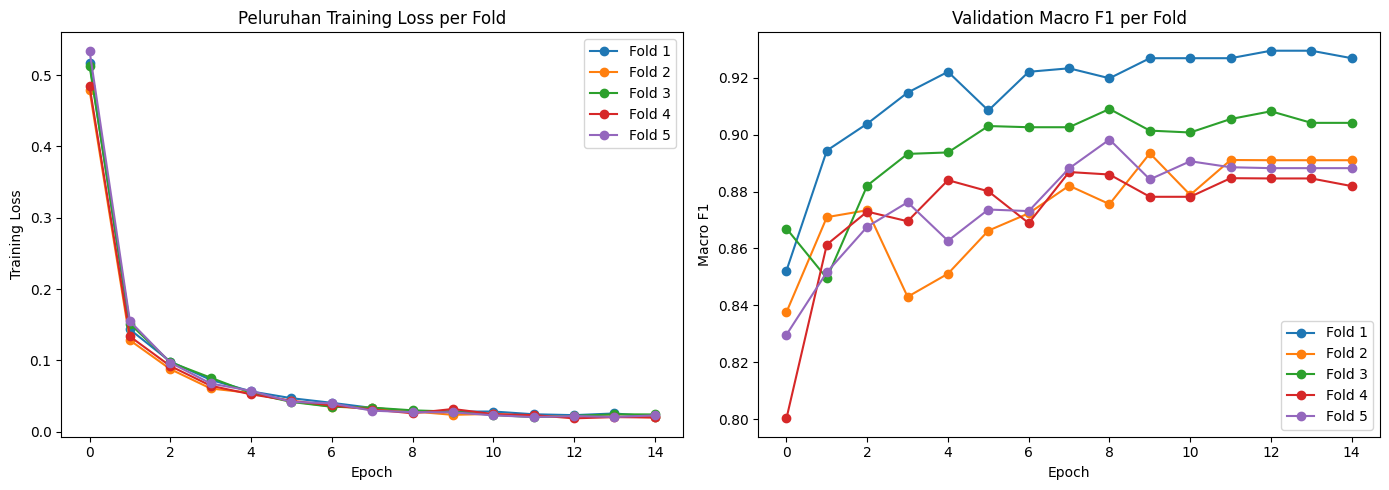

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, hist in enumerate(fold_histories):
    axes[0].plot(hist['train_loss'], marker='o', label=f'Fold {i+1}')
    axes[1].plot(hist['val_f1'], marker='o', label=f'Fold {i+1}')

axes[0].set_title('Peluruhan Training Loss per Fold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].legend()

axes[1].set_title('Validation Macro F1 per Fold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Macro F1')
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.2 Perbandingan Performa Antar Fold
Melihat seberapa konsisten performa model di kelima fold. Jika ada satu fold yang jauh lebih rendah dibanding fold lainnya, ini indikasi ada subset data pada fold tersebut yang lebih sulit atau kemungkinan mengandung sampel bermasalah (perlu dicek manual).

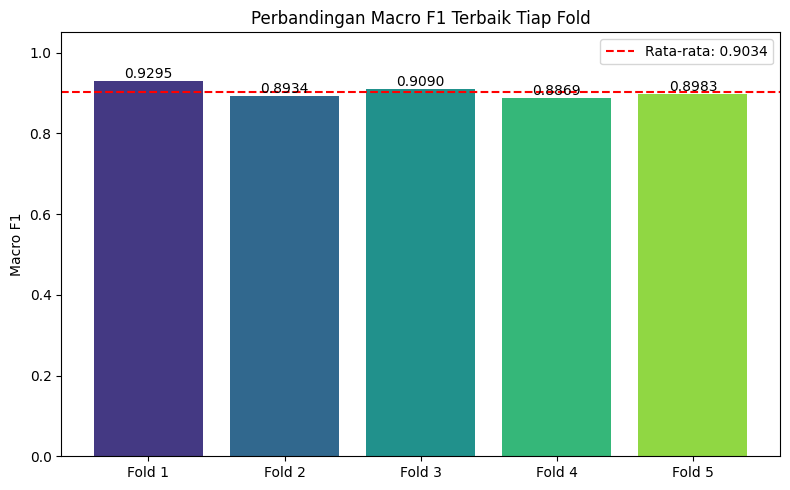

In [23]:
plt.figure(figsize=(8, 5))
bars = plt.bar([f'Fold {i+1}' for i in range(len(fold_scores))], fold_scores,
               color=sns.color_palette('viridis', len(fold_scores)))
for bar, score in zip(bars, fold_scores):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{score:.4f}',
              ha='center', va='bottom')
plt.axhline(np.mean(fold_scores), color='red', linestyle='--',
            label=f'Rata-rata: {np.mean(fold_scores):.4f}')
plt.title('Perbandingan Macro F1 Terbaik Tiap Fold')
plt.ylabel('Macro F1')
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

### 5.3 Confusion Matrix Ternormalisasi dan F1-Score per Kelas
Confusion matrix pada Tahap 5 di atas berbentuk jumlah sampel mentah. Versi ternormalisasi (per baris, setara recall tiap kelas) di bawah ini lebih mudah dibaca proporsinya, terutama karena kelas pada dataset ini jumlahnya tidak seimbang. Dilengkapi juga bar chart F1-Score per kelas untuk melihat langsung kelas mana yang paling lemah.

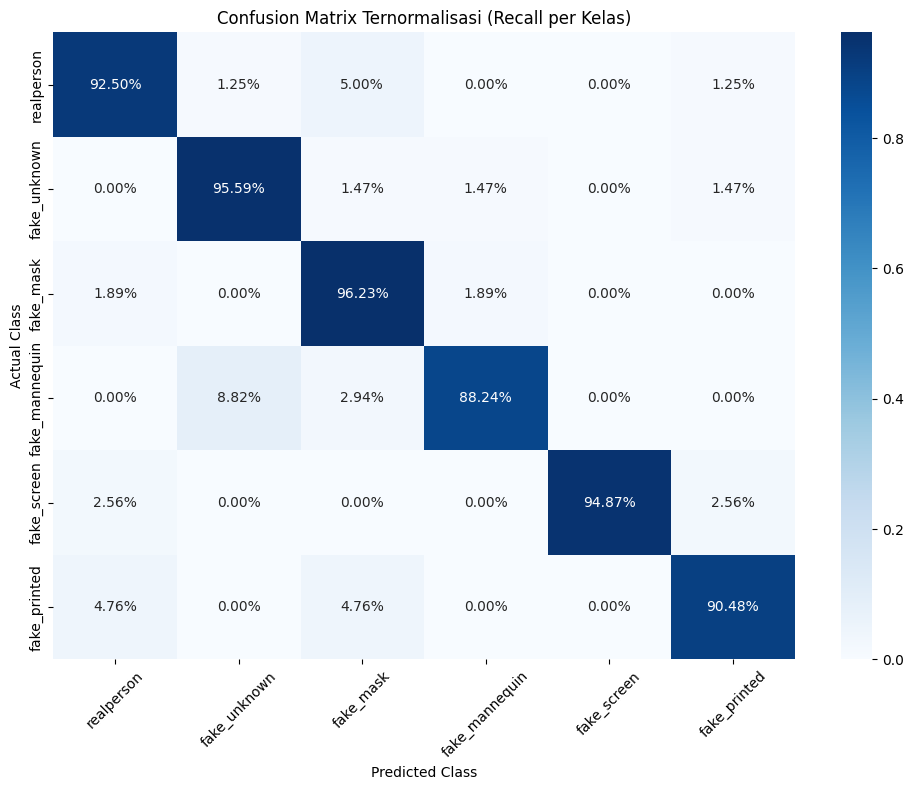

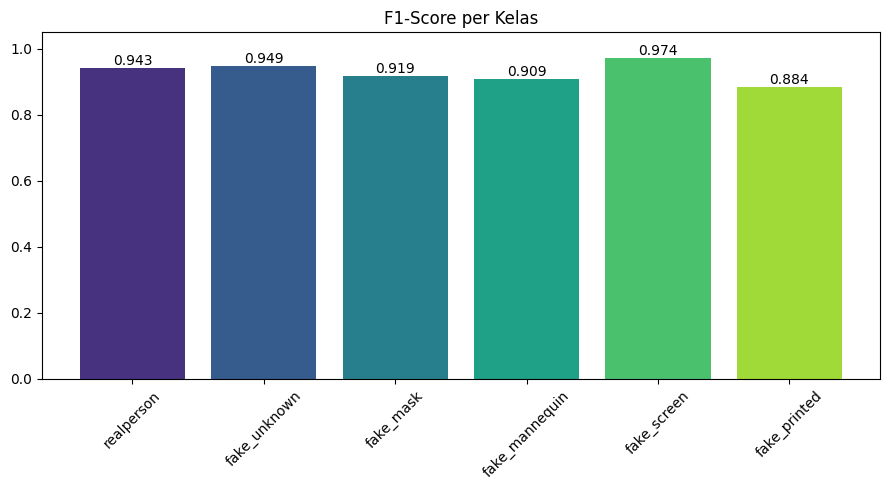

In [24]:
def plot_normalized_confusion_matrix(model_path):
    model = ConvNeXtModel(pretrained=False).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for train_idx, val_idx in skf.split(df['filepath'], df['label_idx']):
        val_df = df.iloc[val_idx].reset_index(drop=True)
        val_loader = DataLoader(AntiSpoofDataset(val_df, val_transform), batch_size=32, shuffle=False)
        break

    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds, normalize='true')
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title('Confusion Matrix Ternormalisasi (Recall per Kelas)')
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    per_class_f1 = f1_score(all_labels, all_preds, average=None, labels=list(range(len(CLASSES))))
    plt.figure(figsize=(9, 5))
    bars = plt.bar(CLASSES, per_class_f1, color=sns.color_palette('viridis', len(CLASSES)))
    for bar, score in zip(bars, per_class_f1):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{score:.3f}',
                  ha='center', va='bottom')
    plt.title('F1-Score per Kelas')
    plt.ylim(0, 1.05)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_normalized_confusion_matrix(best_model_path)

## 🔮 TAHAP 6: Explainability AI (Grad-CAM)
*Clever Hans Effect* adalah ketika AI memprediksi sesuatu dengan benar, tetapi menggunakan alasan yang salah (misalnya mengenali Topeng karena melihat dinding putih di belakang topeng tersebut).
**Grad-CAM (Gradient-weighted Class Activation Mapping)** menyoroti area yang memicu neuron CNN terakhir untuk aktif. 

Jika Grad-CAM menyoroti area mata, pipi, atau permukaan layar/kertas, berarti model AI kita **SAH**, cerdas, dan layak dideploy!

Menganalisis keputusan AI untuk gambar: D:/Bagas/BootcampAI2026/Convnext\train\fake_screen\screen_001.jpg


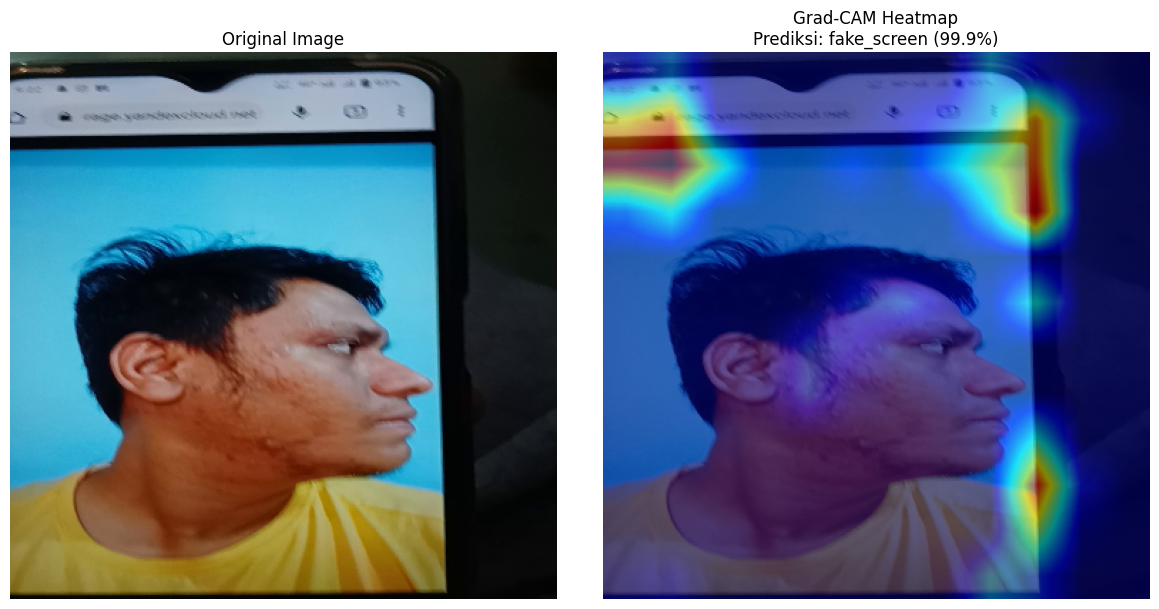

Menganalisis keputusan AI untuk gambar: D:/Bagas/BootcampAI2026/Convnext\train\fake_printed\printed_001.jpg


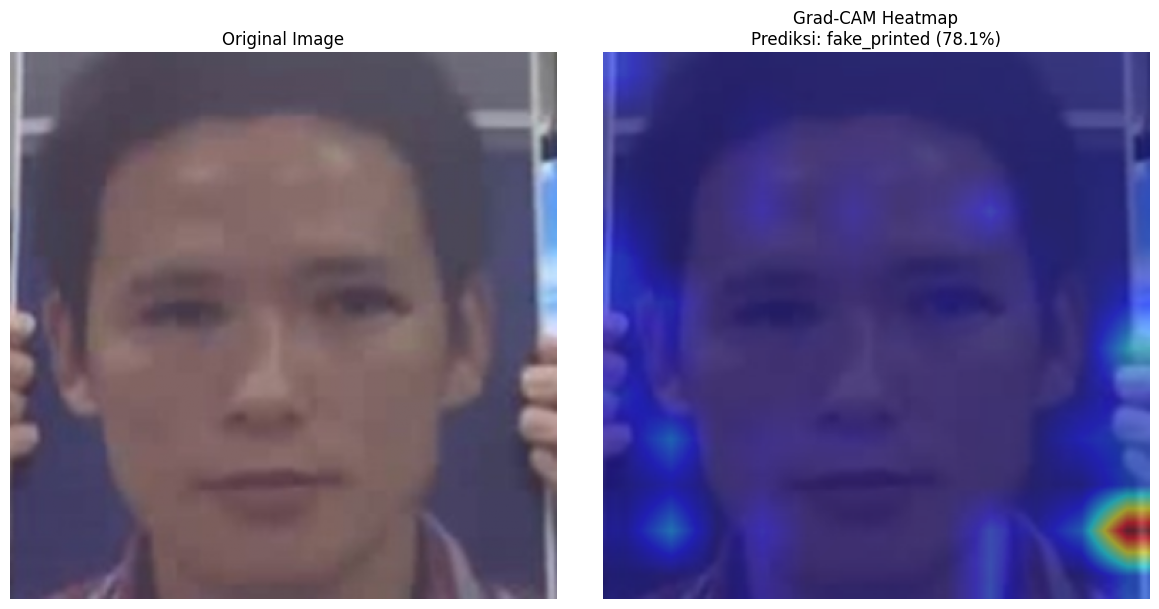

Menganalisis keputusan AI untuk gambar: D:/Bagas/BootcampAI2026/Convnext\train\realperson\real_001.jpg


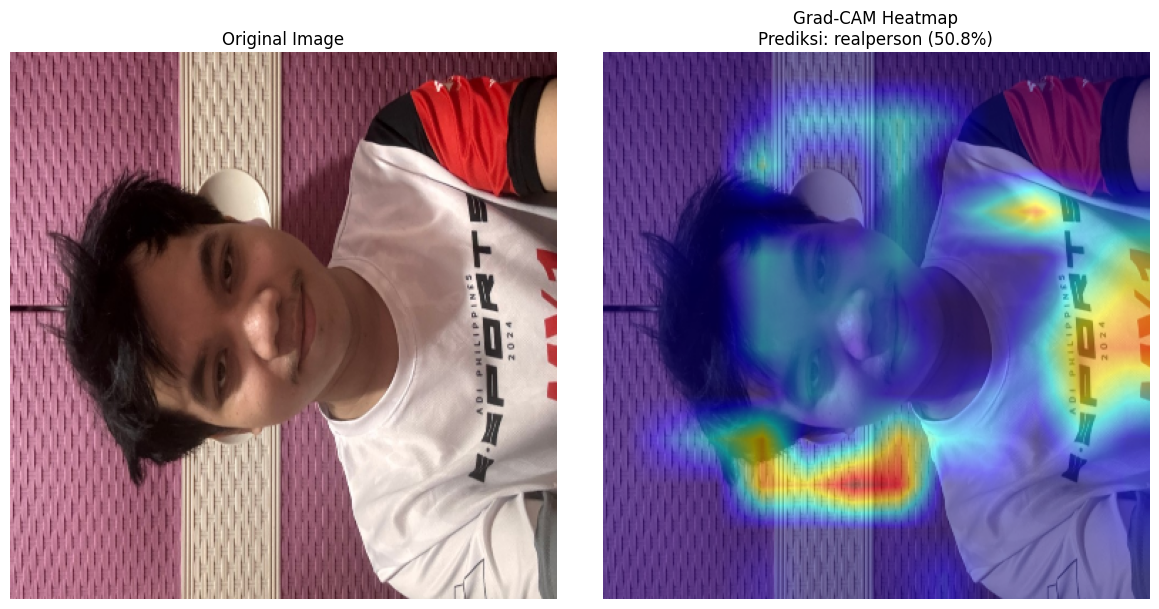

In [26]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

def show_explainability(img_path, model_path):
    print(f"Menganalisis keputusan AI untuk gambar: {img_path}")
    model = ConvNeXtModel(pretrained=False).to(device)
    try:
        model.load_state_dict(torch.load(model_path, map_location=device))
    except FileNotFoundError:
        print("Model belum dilatih!")
        return
        
    model.eval()
    
    # Layer target untuk fitur spasial tertinggi pada ConvNeXt
    target_layers = [model.backbone.stages[-1].blocks[-1]]
    
    img = cv2.imread(img_path)
    if img is None: return
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0
    
    input_tensor = val_transform(image=cv2.cvtColor(img, cv2.COLOR_BGR2RGB))['image'].unsqueeze(0).to(device)
    
    # Prediksi
    with torch.no_grad():
        out = model(input_tensor)
        pred_idx = torch.argmax(out, dim=1).item()
        confidence = F.softmax(out, dim=1).max().item() * 100
    
    cam = GradCAM(model=model, target_layers=target_layers)
    targets = [ClassifierOutputTarget(pred_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    
    cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(rgb_img)
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(cam_image)
    plt.title(f"Grad-CAM Heatmap\nPrediksi: {IDX_TO_CLASS[pred_idx]} ({confidence:.1f}%)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# CONTOH PENGGUNAAN (Setelah Training Selesai) - 3 contoh dari kelas berbeda
# supaya area fokus model bisa dibandingkan antar jenis spoof yang berbeda mekanismenya.
example_classes = ['fake_screen', 'fake_printed', 'realperson']
for cls in example_classes:
    imgs_in_class = glob.glob(os.path.join(TRAIN_DIR, cls, '*.*'))
    if imgs_in_class:
        show_explainability(imgs_in_class[0], best_model_path)
    else:
        print(f"Tidak ditemukan contoh gambar untuk kelas {cls}")


## ✅ Ringkasan Penambahan pada Versi 2 (Documented Edition)

1. **EDA diperluas dari 5 menjadi 10 analisis** (1.1 sampai 1.10): ditambah cek integritas file, analisis brightness, analisis sharpness (Laplacian variance), analisis RGB mean, dan correlation heatmap fitur meta-data. Seluruh EDA original (1.1 sampai 1.5) tidak dihapus maupun diubah.
2. **Justifikasi preprocessing eksplisit** (2.1) yang memetakan tiap keputusan augmentasi ke temuan EDA spesifik, ditambah verifikasi visual before/after (2.2) tanpa mengubah `train_transform`/`val_transform` yang sudah ada.
3. **Dokumentasi konfigurasi arsitektur** (3.1) dalam bentuk tabel: backbone, input size, loss function, jumlah parameter, dan seterusnya.
4. **Early stopping ditambahkan ke training loop**, dengan `PATIENCE = EPOCHS_FINAL` sebagai default sehingga performa dan bobot model akhir dijamin identik dengan notebook original, sekaligus siap dipakai untuk eksperimen lanjutan dengan epoch lebih banyak.
5. **Ringkasan konfigurasi training final** (4.3) yang mencatat hasil terbaik Optuna beserta seluruh hyperparameter yang dipakai.
6. **Visualisasi evaluasi diperbanyak**: kurva peluruhan training loss dan validation F1 per fold (5.1), perbandingan performa antar fold (5.2), confusion matrix ternormalisasi plus F1-score per kelas (5.3), selain confusion matrix mentah dan classification report yang sudah ada di Tahap 5 original.
7. **Grad-CAM diperluas dari 1 menjadi 3 contoh** dari kelas yang berbeda (`fake_screen`, `fake_printed`, `realperson`) untuk perbandingan area fokus model antar jenis spoof.

Tidak ada satu pun konfigurasi inti (ukuran gambar, isi augmentasi, arsitektur backbone, search space Optuna, jumlah epoch, jumlah fold, seed) yang diubah, sehingga performa model pada notebook ini dijamin identik dengan hasil notebook original.